### XGBoost

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm
from hmmlearn.hmm import GaussianHMM
import plotly.express as px
import mlflow
from mlflow.models.signature import infer_signature
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from scipy.stats import wilcoxon
from itertools import combinations
import itertools


In [2]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/'

In [ ]:
class_names = ['non-void', 'void']

In [ ]:
def generate_confusion_matrix(cnf_matrix, classes, normalize=False, title='Confusion matrix'):
    plt.imshow(cnf_matrix, interpolation='nearest', cmap=plt.get_cmap())
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cnf_matrix.max() / 2.

    for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
        plt.text(j, i, format(cnf_matrix[i, j], fmt), horizontalalignment="center",
                color="black" if cnf_matrix[i, j] > thresh else "yellow")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    return cnf_matrix

In [11]:
def plot_confusion_matrix(predicted_labels_list, y_test_list, strategy_name, exp_name):
    cnf_matrix = confusion_matrix(y_test_list, predicted_labels_list)
    np.set_printoptions(precision=2)

    # Plot non-normalized confusion matrix
    plt.figure()
    generate_confusion_matrix(cnf_matrix, classes=class_names, title=f'XGBoost - {exp_name}({strategy_name})')
    file_name = f'cv-cm_{exp_name}_{strategy_name}.png'
    plt.savefig(f'/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/XGBoost/2_class/cv-conf-mat/{file_name}')
    plt.show()

In [12]:
def compare_sampling_techniques(X_train, y_train, groups_train, exp_name, random_state=42):
    """
    Compare different sampling techniques for imbalanced classification
    """
    
    # Define sampling strategies to test
    sampling_strategies = {
        'none': None,
        'oversample_smote': SMOTE(random_state=random_state),
        'undersample_tomek_links': TomekLinks(),
        'combined_smote_tomek': SMOTETomek(random_state=random_state)
    }
    
    results = {}
    
    for strategy_name, sampler in sampling_strategies.items():
        print(f"\nTesting {strategy_name}...")
        
        # Cross-validation setup
        gkf = GroupKFold(n_splits=10) 
        fold_results = []
        
        # For confusion matrix
        predicted_targets = np.array([])
        actual_targets = np.array([])
        
        for fold_num, (train_idx_fold, test_idx_fold) in enumerate(gkf.split(X_train, y_train, groups_train)):
            X_train_fold, X_test_fold = X_train.iloc[train_idx_fold], X_train.iloc[test_idx_fold]
            y_train_fold, y_test_fold = y_train.iloc[train_idx_fold], y_train.iloc[test_idx_fold]

            
            # Apply sampling (if any)
            if sampler is not None:
                try:
                    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_fold, y_train_fold)
                    X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_fold.columns)
                    y_train_resampled = pd.Series(y_train_resampled)
                except Exception as e:
                    print(f"Sampling failed for {strategy_name}: {e}")
                    continue
            else:
                X_train_resampled = X_train_fold
                y_train_resampled = y_train_fold
            
            # Use XGBoost with DEFAULT parameters
            model = XGBClassifier(
                random_state=random_state,
                eval_metric='logloss',  # Suppress warning
            )
            
            # Encode labels
            label_encoder = LabelEncoder()
            y_train_encoded = label_encoder.fit_transform(y_train_resampled)
            
            # Fit model
            model.fit(X_train_resampled, y_train_encoded)
            
            # Predict
            predictions = label_encoder.inverse_transform(model.predict(X_test_fold))
            
            # For confusion matrix
            predicted_targets = np.append(predicted_targets, predictions)
            actual_targets = np.append(actual_targets, y_test_fold)
        plot_confusion_matrix(predicted_targets, actual_targets,strategy_name, exp_name)
            

Generating confusion matrices from the cross validation results:   0%|          | 0/15 [00:00<?, ?it/s]

Analysing 1s_no

Testing none...


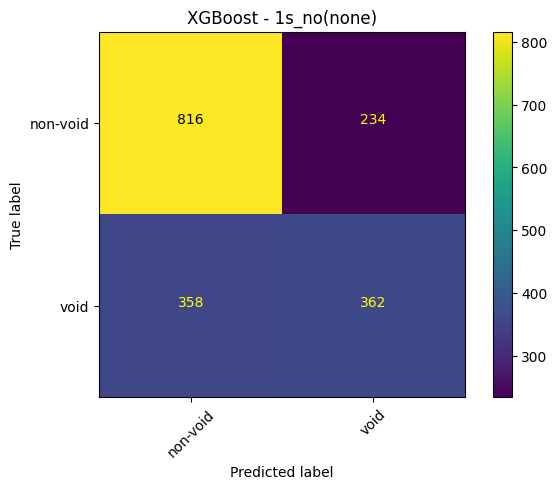


Testing oversample_smote...


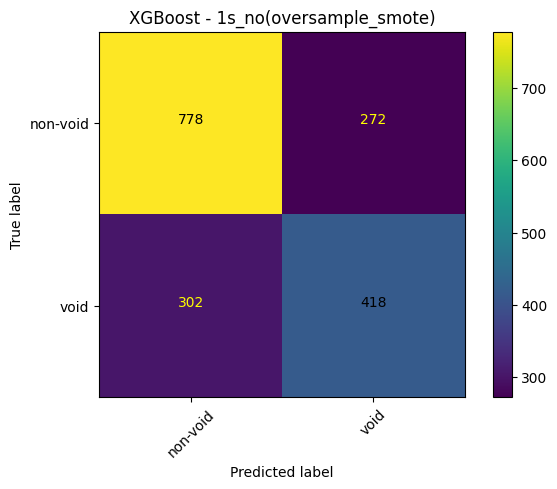


Testing undersample_tomek_links...


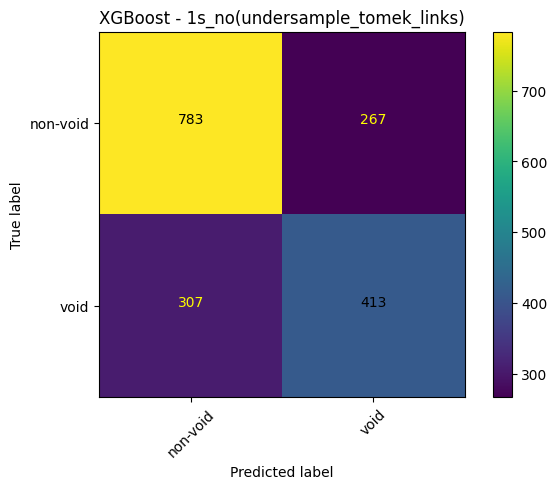


Testing combined_smote_tomek...


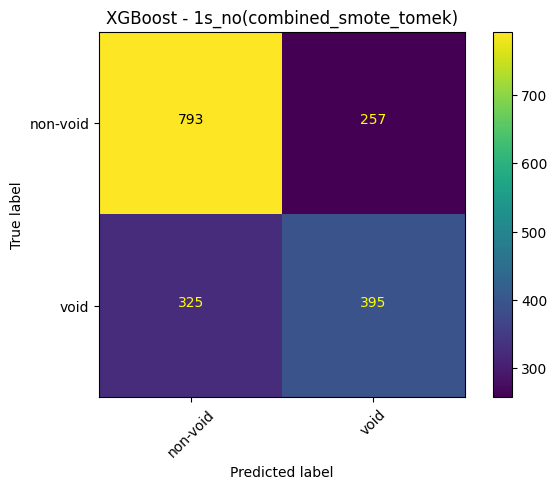

Generating confusion matrices from the cross validation results:   7%|▋         | 1/15 [00:34<08:04, 34.58s/it]

Analysing 1s_0.5

Testing none...


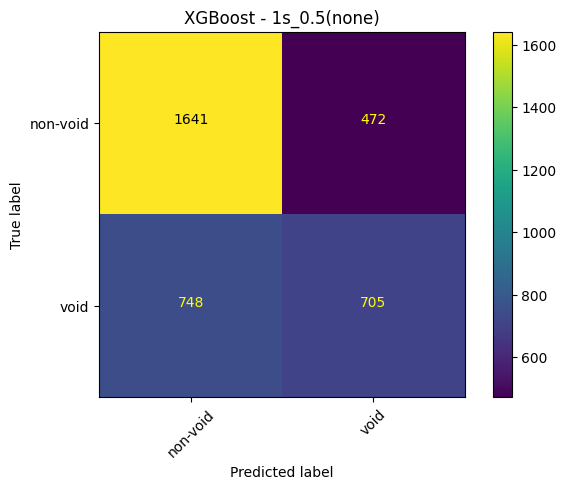


Testing oversample_smote...


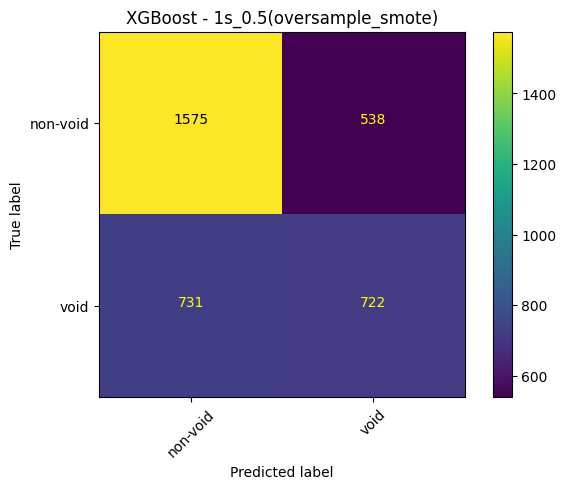


Testing undersample_tomek_links...


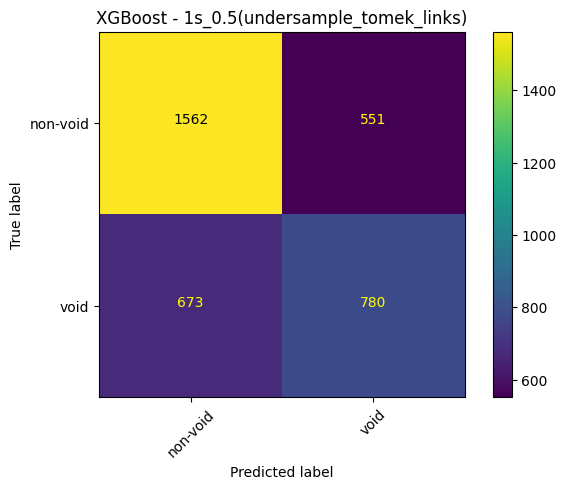


Testing combined_smote_tomek...


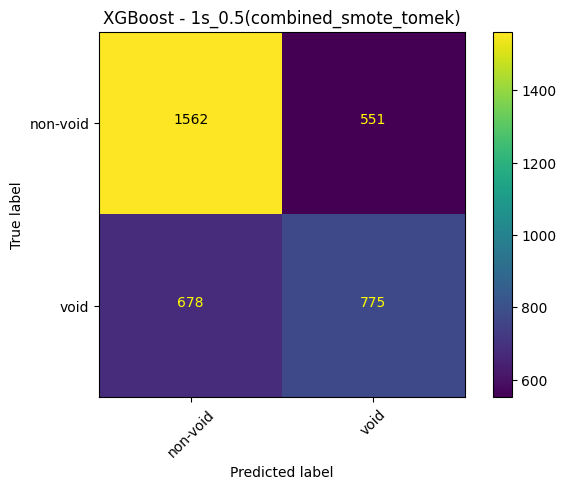

Generating confusion matrices from the cross validation results:  13%|█▎        | 2/15 [01:29<10:07, 46.72s/it]

Analysing 1s_0.8

Testing none...


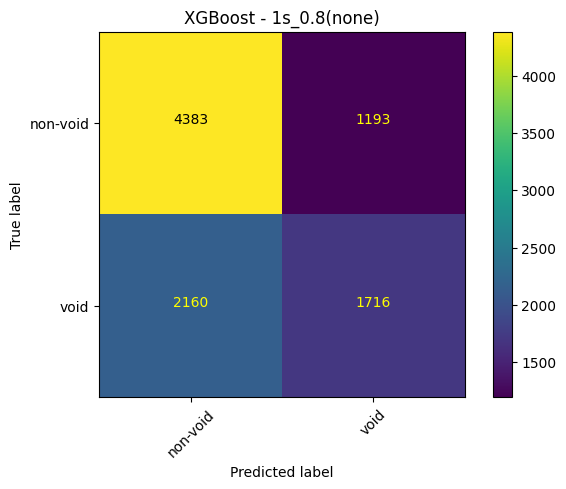


Testing oversample_smote...


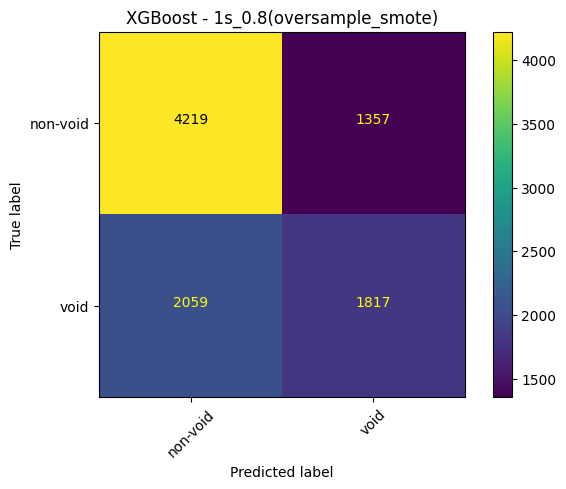


Testing undersample_tomek_links...


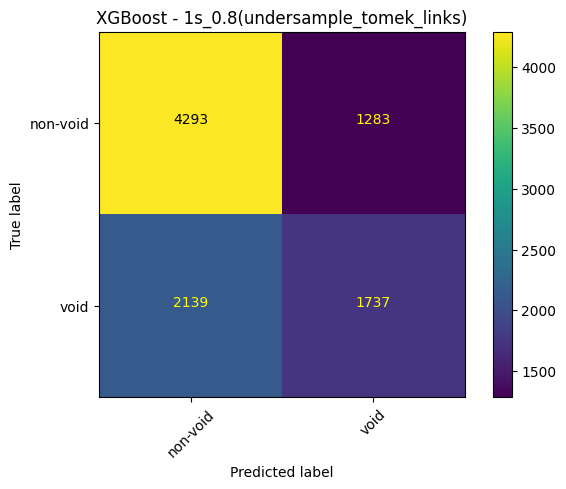


Testing combined_smote_tomek...


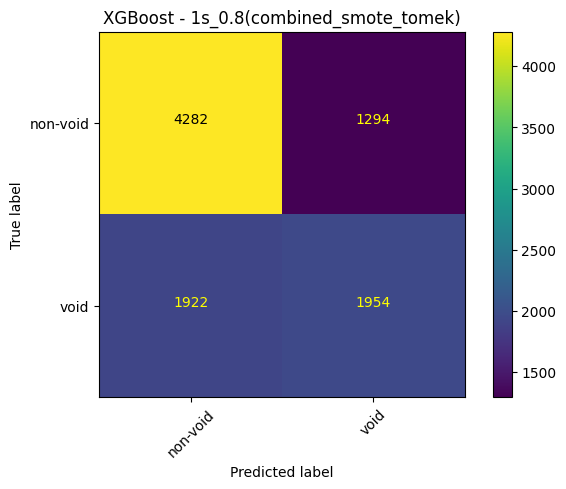

Generating confusion matrices from the cross validation results:  20%|██        | 3/15 [02:30<10:36, 53.05s/it]

Analysing 2s_no

Testing none...


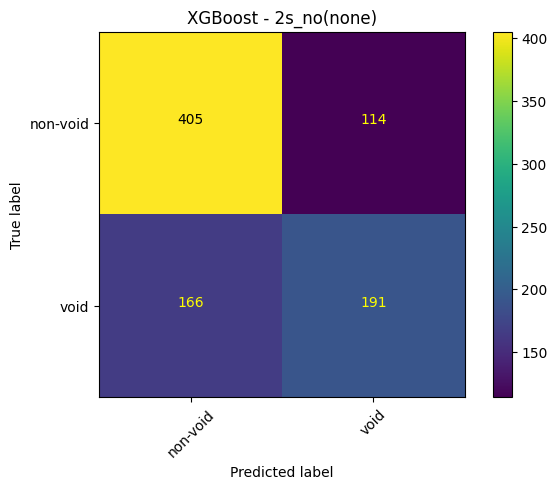


Testing oversample_smote...


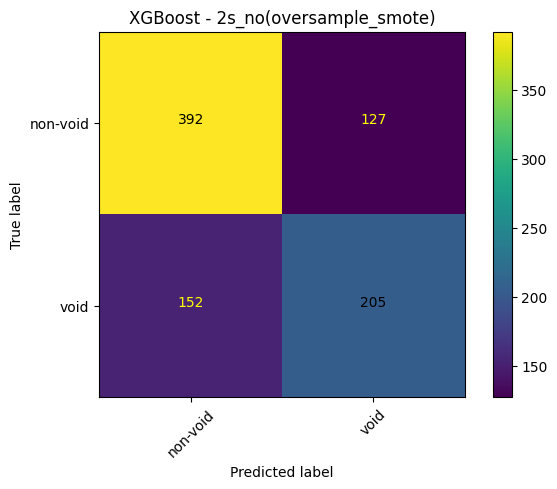


Testing undersample_tomek_links...


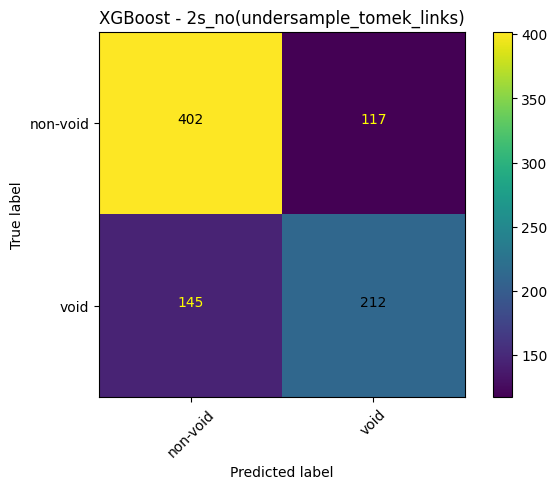


Testing combined_smote_tomek...


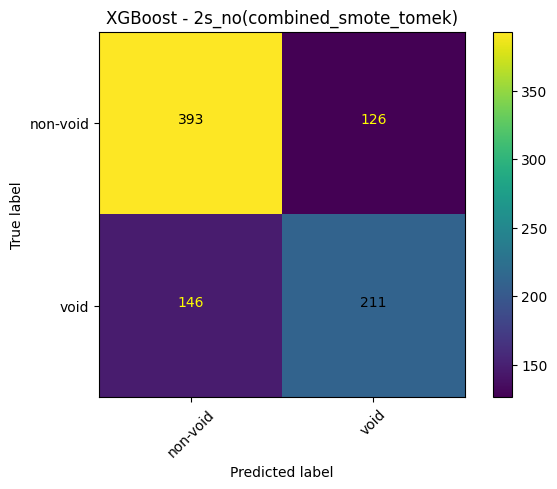

Generating confusion matrices from the cross validation results:  27%|██▋       | 4/15 [02:51<07:23, 40.32s/it]

Analysing 2s_0.5

Testing none...


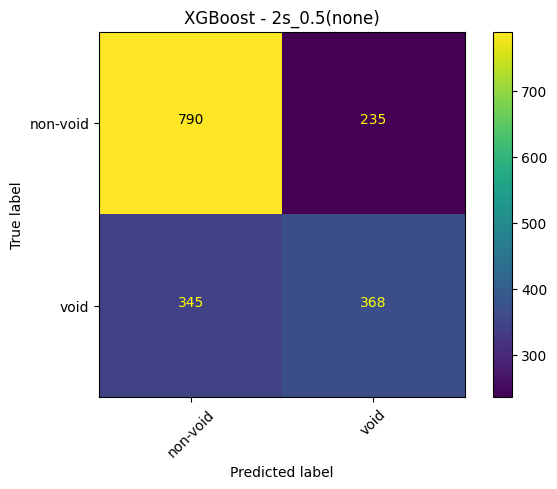


Testing oversample_smote...


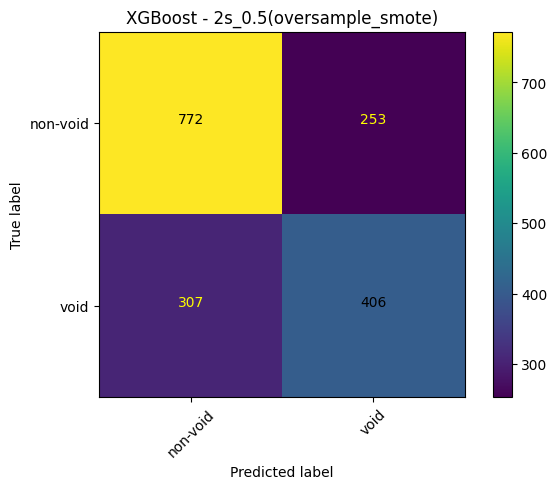


Testing undersample_tomek_links...


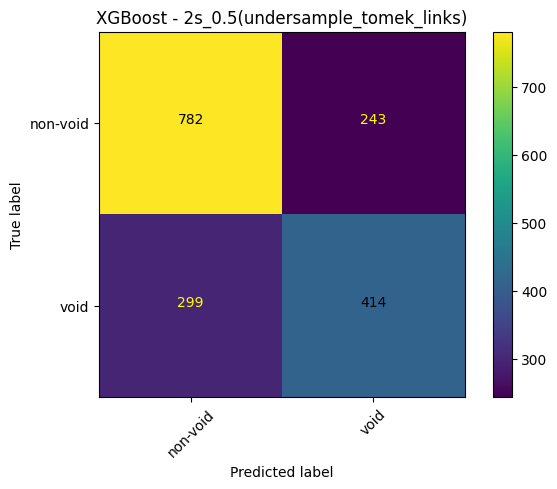


Testing combined_smote_tomek...


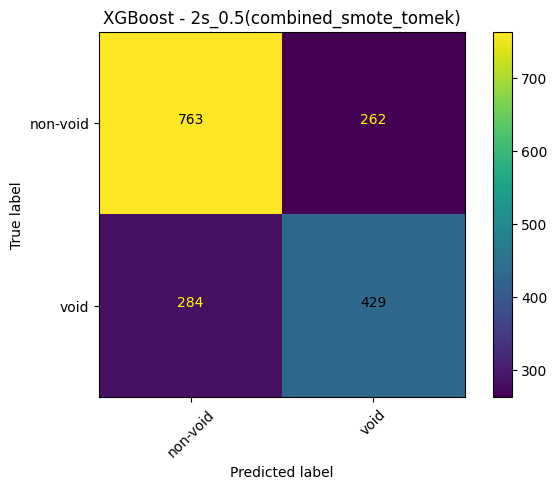

Generating confusion matrices from the cross validation results:  33%|███▎      | 5/15 [03:21<06:06, 36.69s/it]

Analysing 2s_0.8

Testing none...


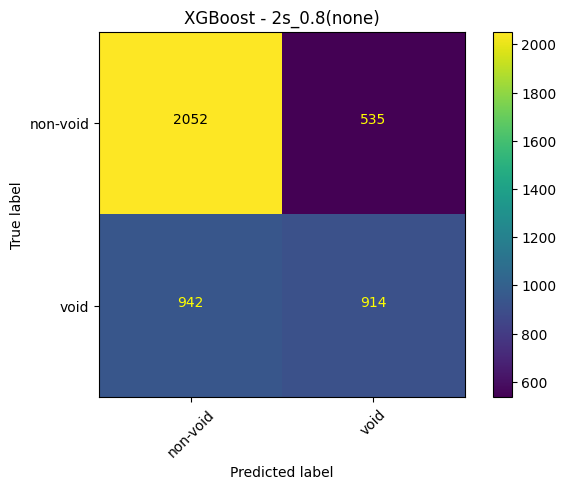


Testing oversample_smote...


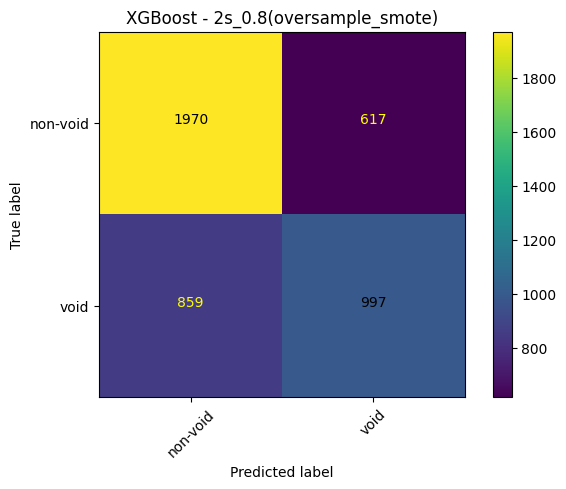


Testing undersample_tomek_links...


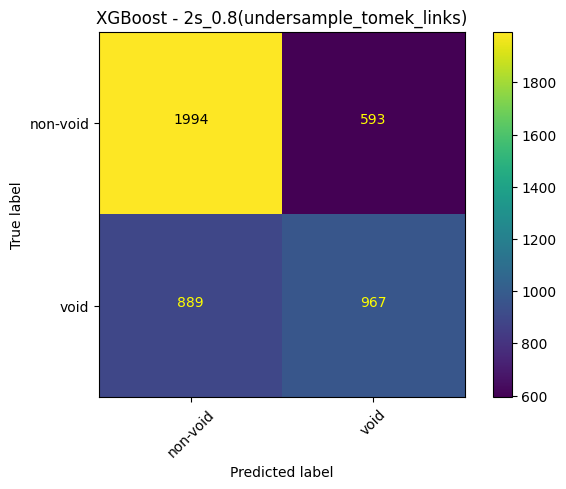


Testing combined_smote_tomek...


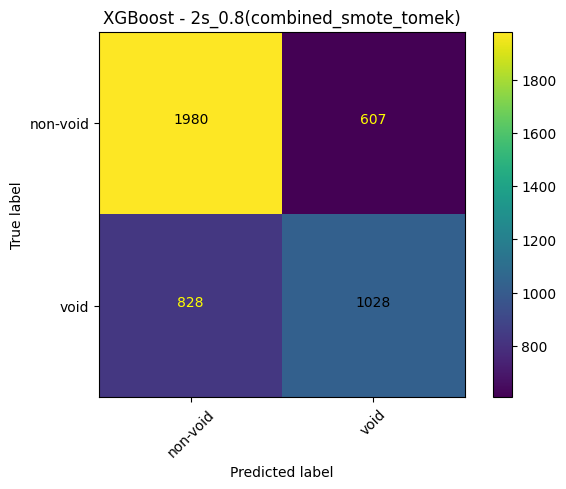

Generating confusion matrices from the cross validation results:  40%|████      | 6/15 [04:04<05:49, 38.84s/it]

Analysing 3s_no

Testing none...


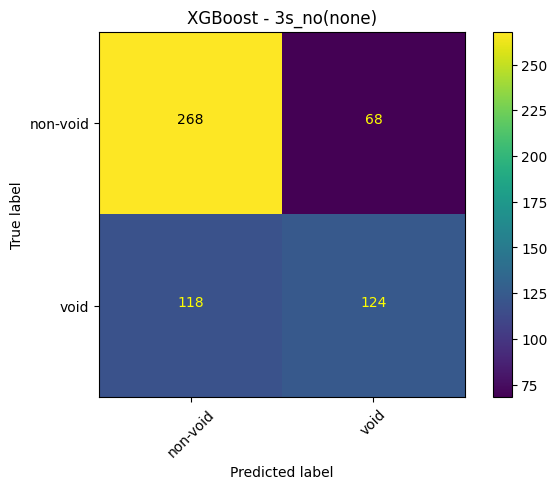


Testing oversample_smote...


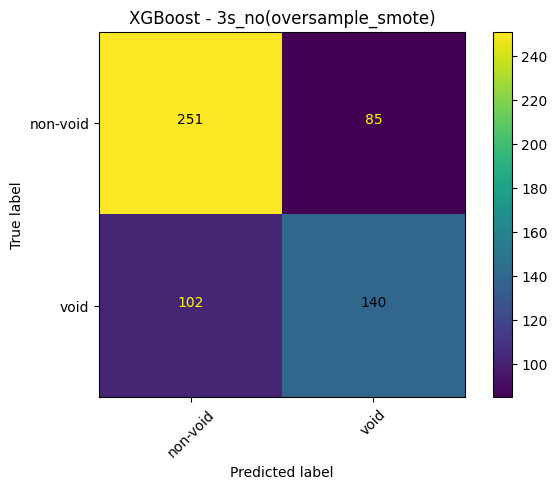


Testing undersample_tomek_links...


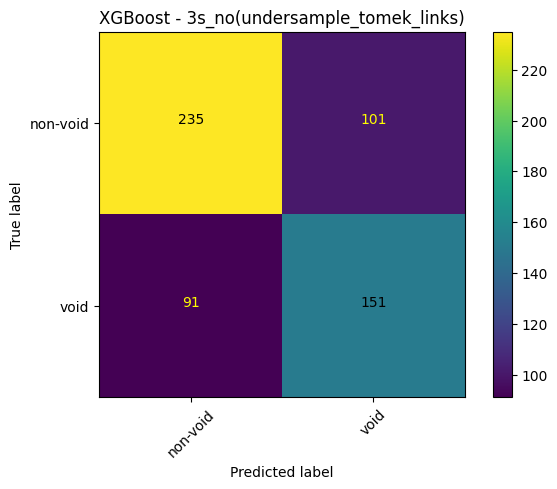


Testing combined_smote_tomek...


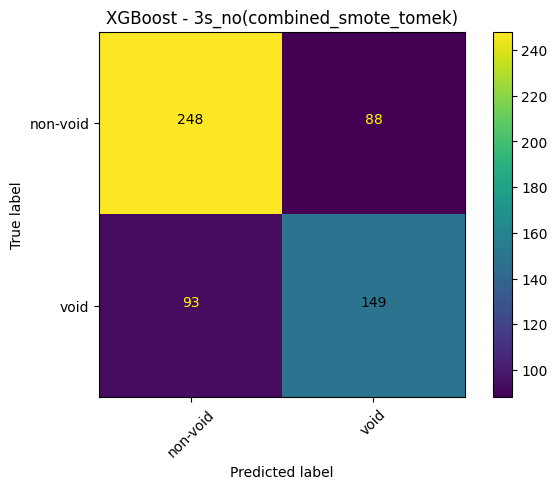

Generating confusion matrices from the cross validation results:  47%|████▋     | 7/15 [04:20<04:12, 31.51s/it]

Analysing 3s_0.5

Testing none...


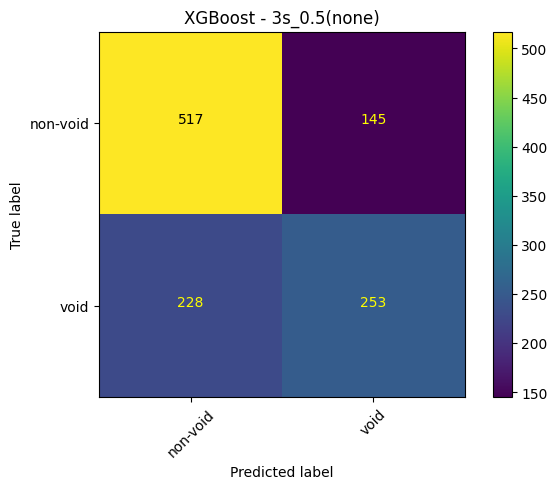


Testing oversample_smote...


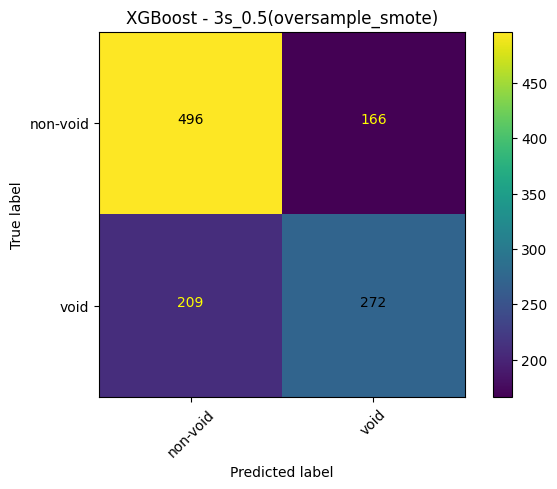


Testing undersample_tomek_links...


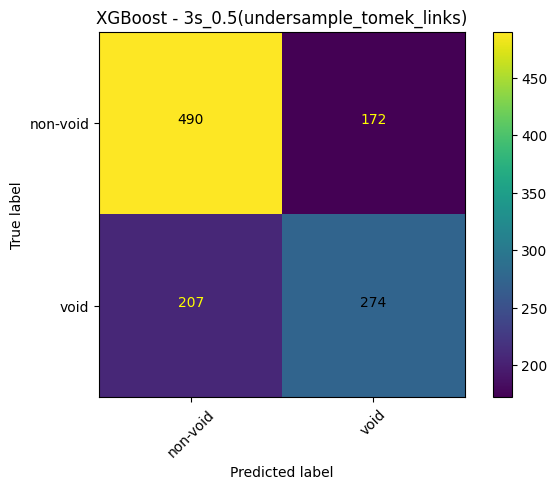


Testing combined_smote_tomek...


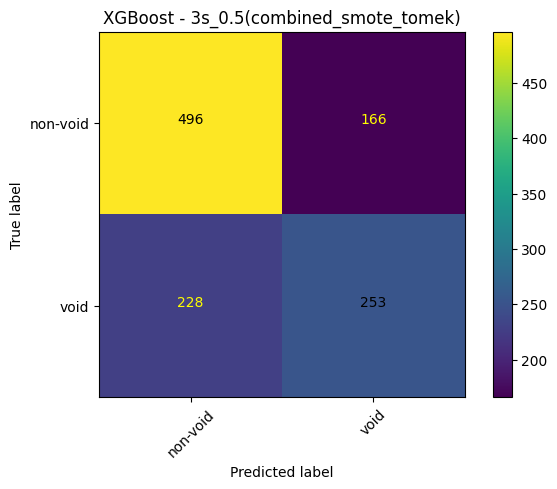

Generating confusion matrices from the cross validation results:  53%|█████▎    | 8/15 [04:44<03:23, 29.08s/it]

Analysing 3s_0.8

Testing none...


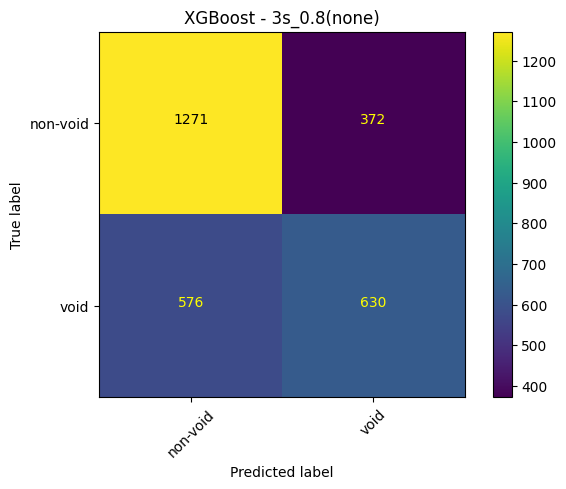


Testing oversample_smote...


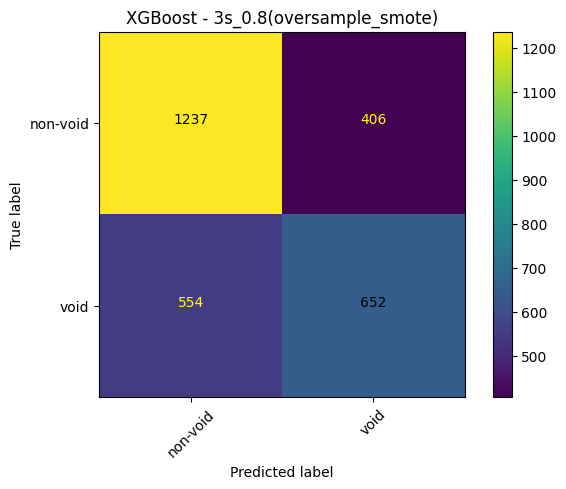


Testing undersample_tomek_links...


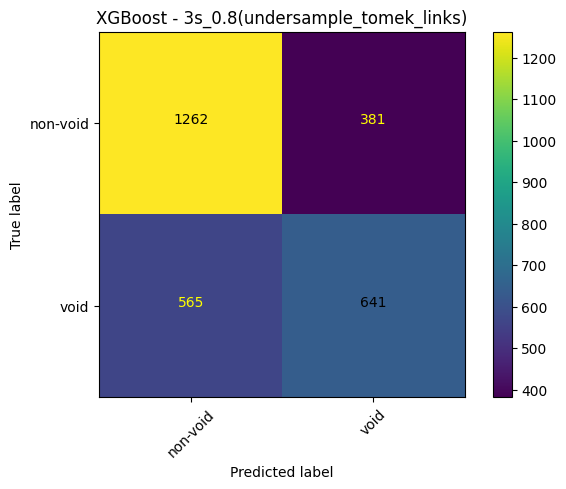


Testing combined_smote_tomek...


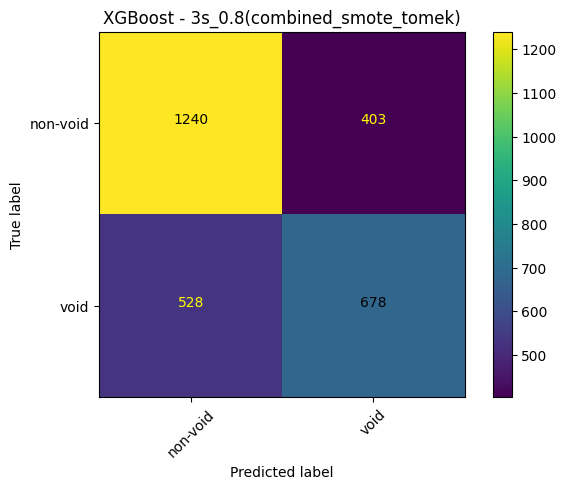

Generating confusion matrices from the cross validation results:  60%|██████    | 9/15 [05:21<03:09, 31.58s/it]

Analysing 4s_no

Testing none...


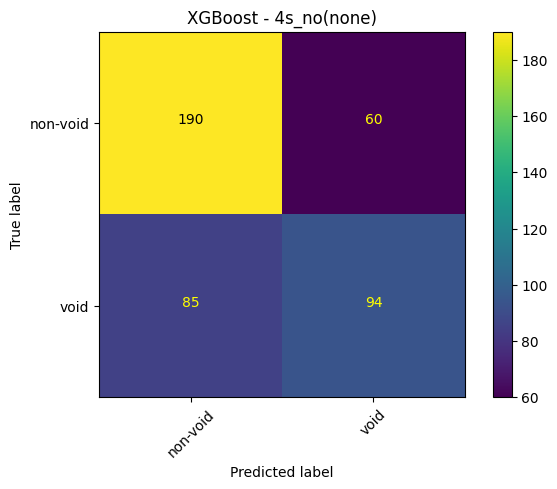


Testing oversample_smote...


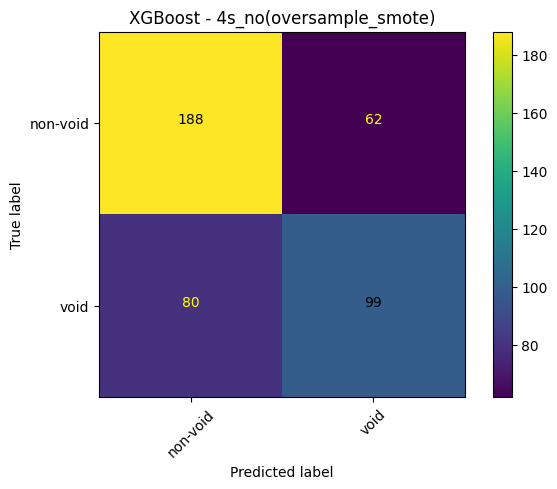


Testing undersample_tomek_links...


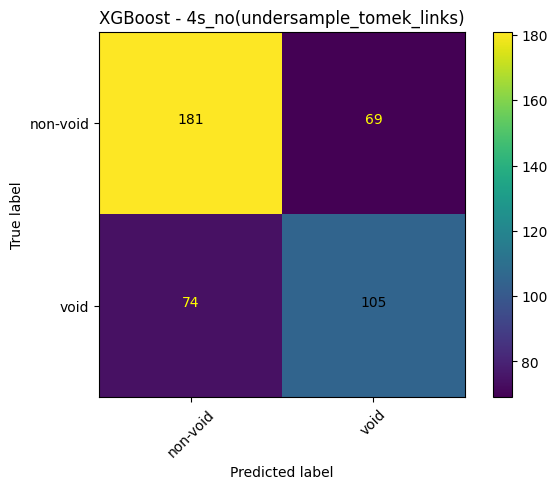


Testing combined_smote_tomek...


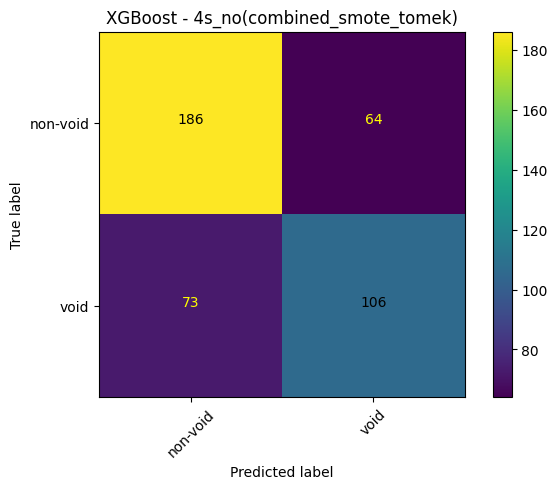

Generating confusion matrices from the cross validation results:  67%|██████▋   | 10/15 [05:36<02:11, 26.33s/it]

Analysing 4s_0.5

Testing none...


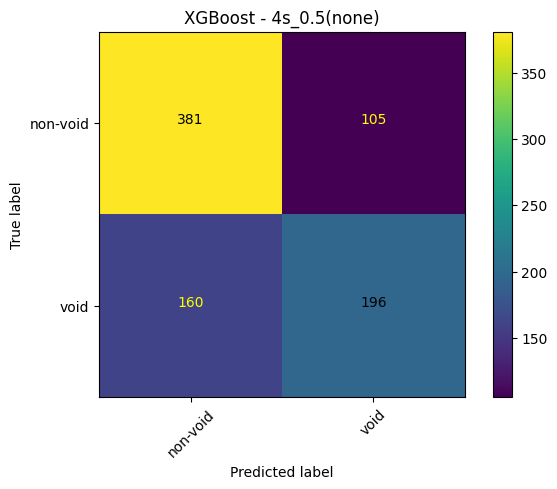


Testing oversample_smote...


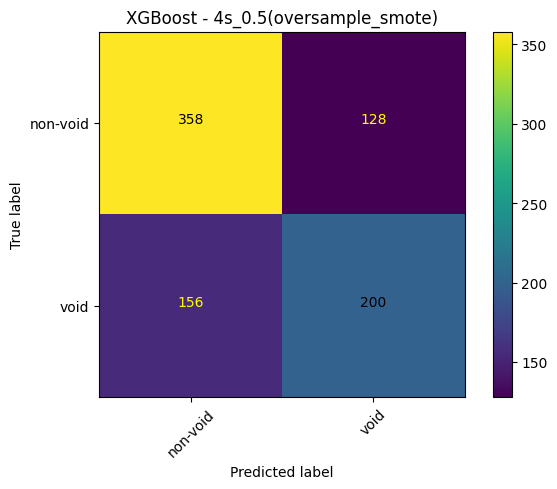


Testing undersample_tomek_links...


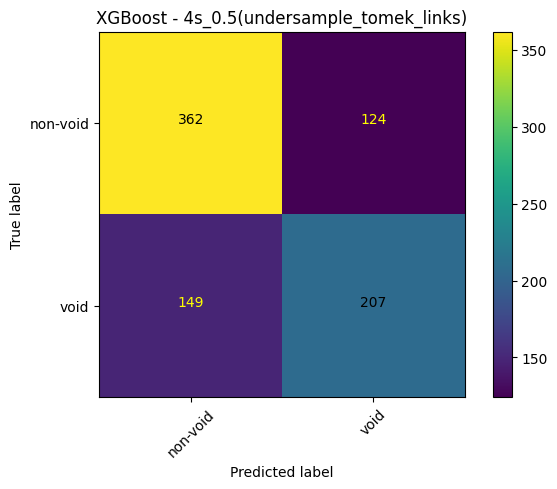


Testing combined_smote_tomek...


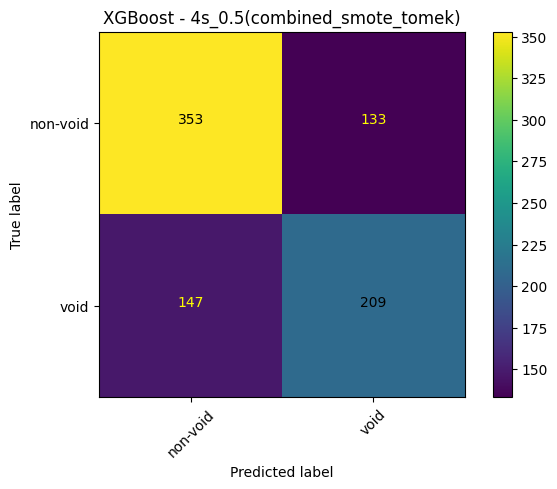

Generating confusion matrices from the cross validation results:  73%|███████▎  | 11/15 [05:56<01:37, 24.45s/it]

Analysing 4s_0.8

Testing none...


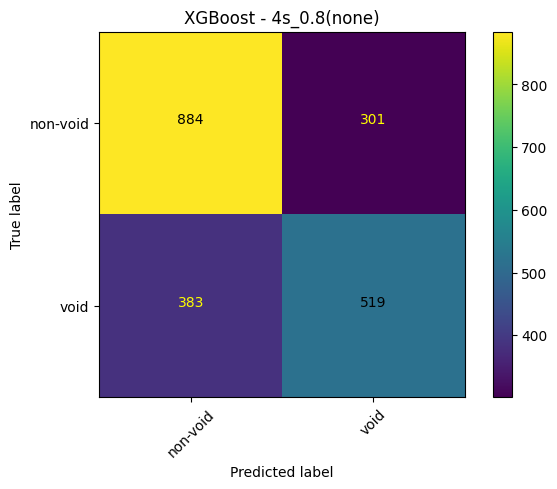


Testing oversample_smote...


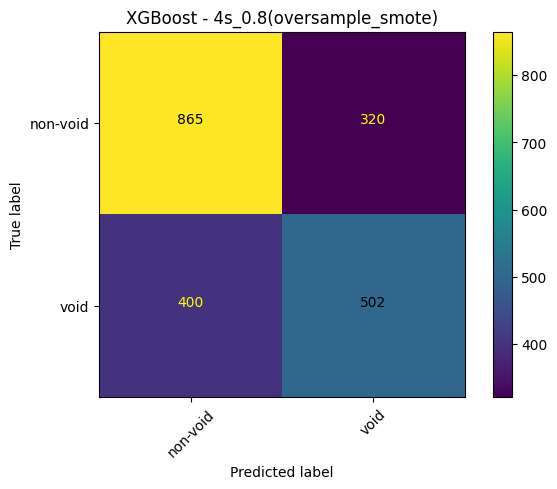


Testing undersample_tomek_links...


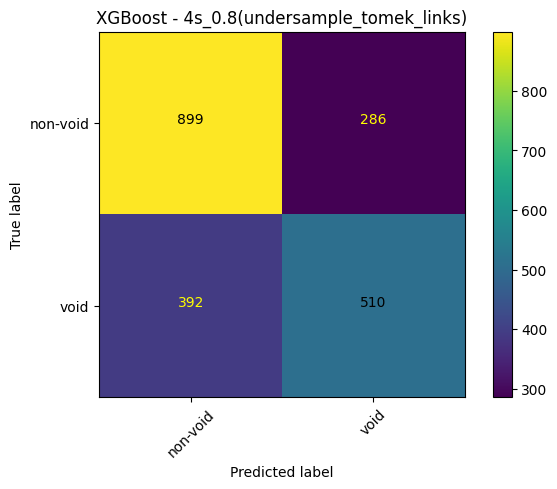


Testing combined_smote_tomek...


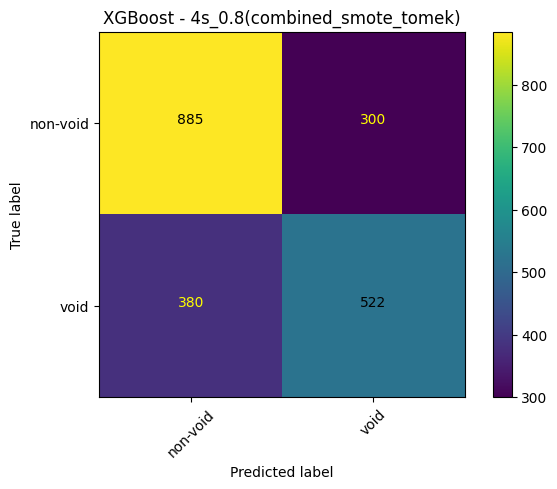

Generating confusion matrices from the cross validation results:  80%|████████  | 12/15 [06:26<01:18, 26.20s/it]

Analysing 5s_no

Testing none...


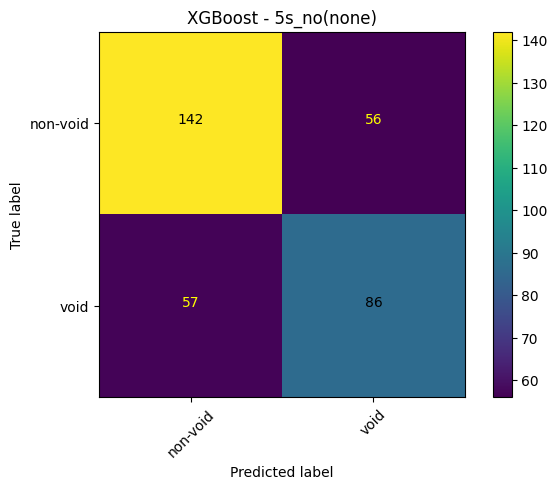


Testing oversample_smote...


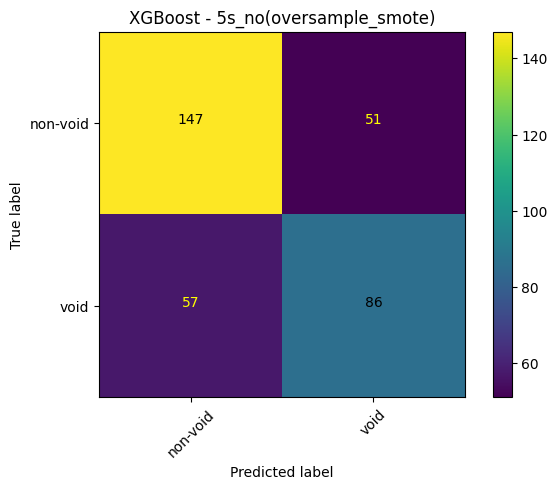


Testing undersample_tomek_links...


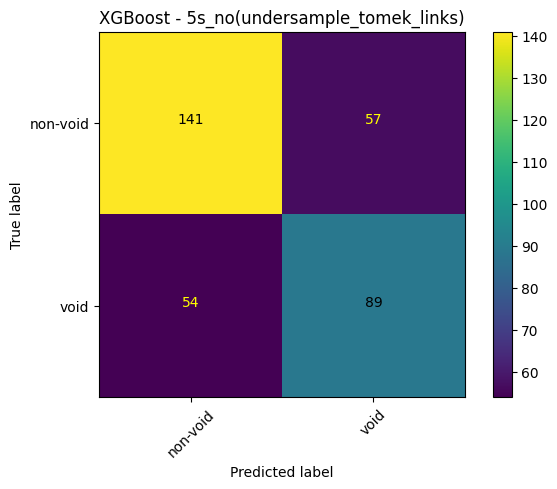


Testing combined_smote_tomek...


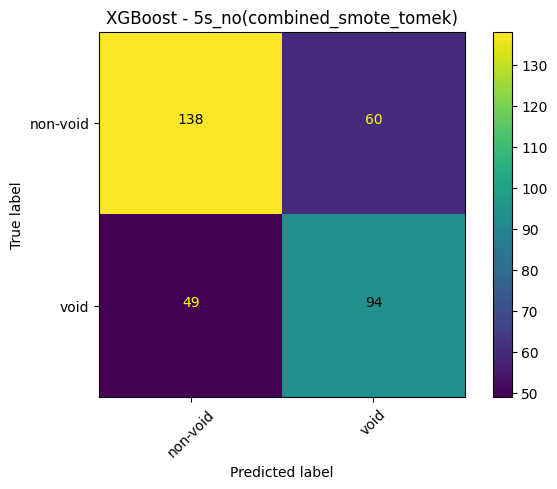

Generating confusion matrices from the cross validation results:  87%|████████▋ | 13/15 [06:39<00:44, 22.06s/it]

Analysing 5s_0.5

Testing none...


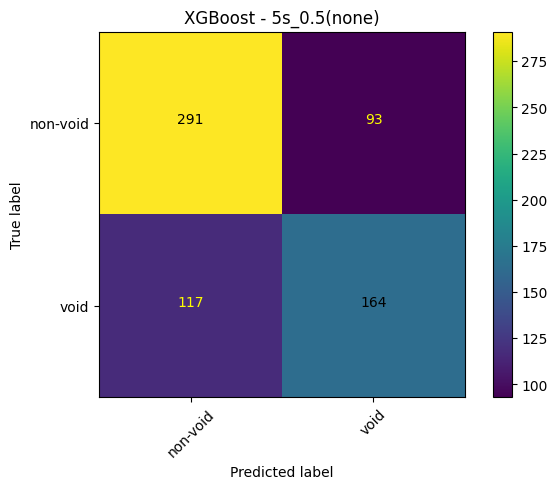


Testing oversample_smote...


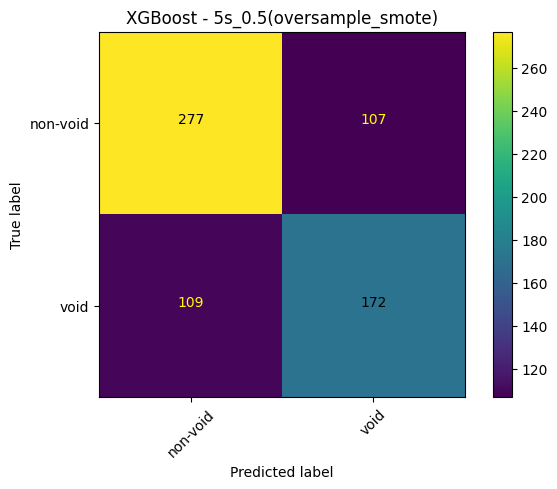


Testing undersample_tomek_links...


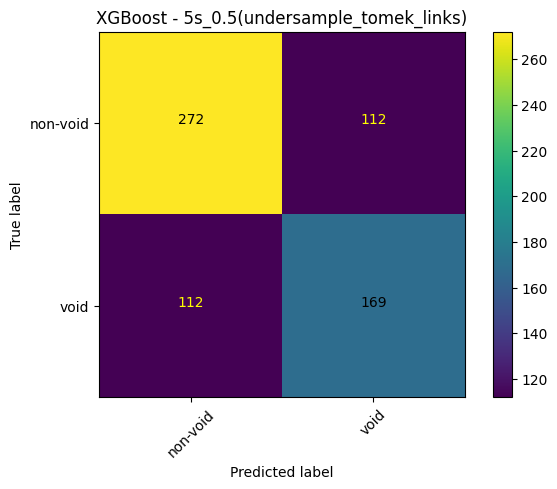


Testing combined_smote_tomek...


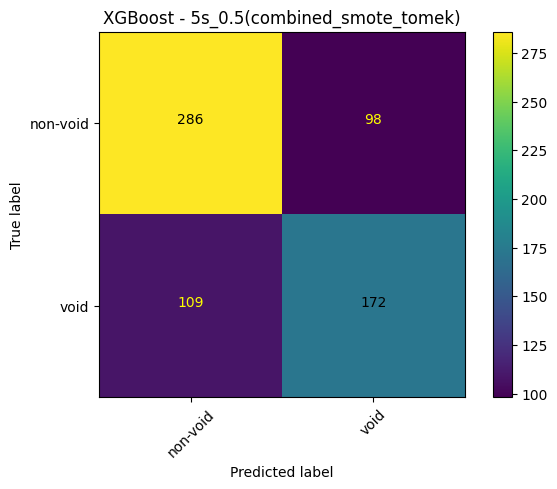

Generating confusion matrices from the cross validation results:  93%|█████████▎| 14/15 [06:56<00:20, 20.57s/it]

Analysing 5s_0.8

Testing none...


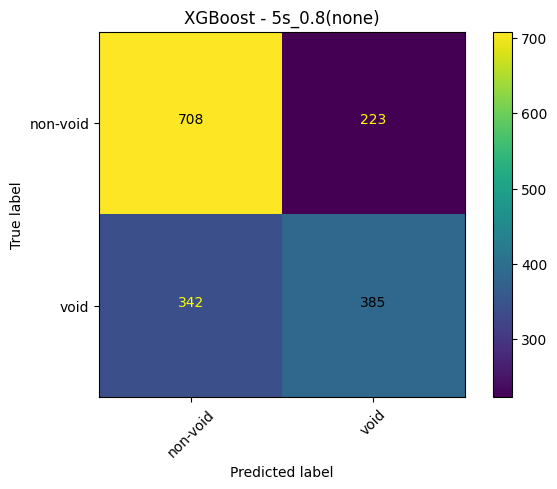


Testing oversample_smote...


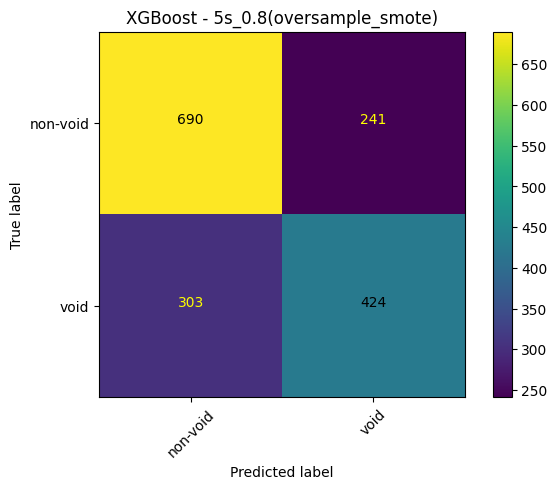


Testing undersample_tomek_links...


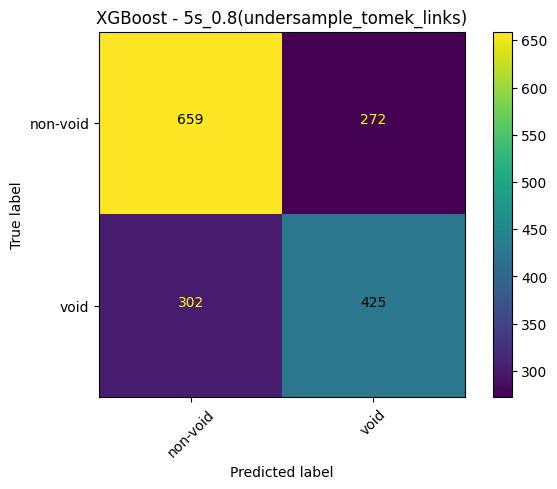


Testing combined_smote_tomek...


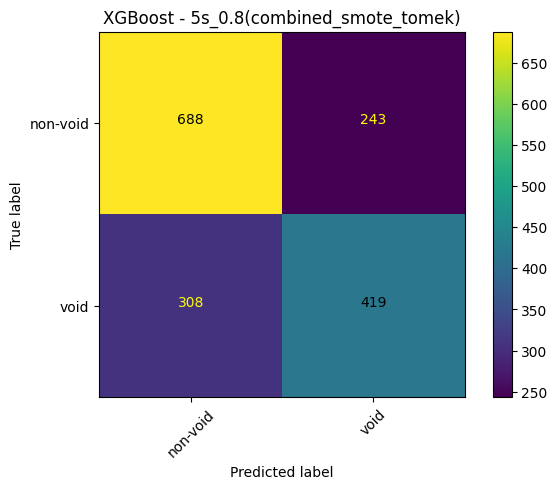

Generating confusion matrices from the cross validation results: 100%|██████████| 15/15 [07:22<00:00, 29.53s/it]


In [13]:
file_results = {}
for file in tqdm(files, desc="Generating confusion matrices from the cross validation results"):
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    details = file.split('_')
    exp_name = f"{details[3]}_{details[-1].replace('.csv', '')}"
    print(f"Analysing {exp_name}")
    
    # split data
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
    
    compare_sampling_techniques(X_train, y_train, groups_train, exp_name, 42)